In [32]:
import sys

import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from astropy.table import Table

# 'services', 'model_functions' e 'iSpec_functions' están en 'models', así que
# hay que poner esa carpeta en 'sys.path' antes de importarlos. Para eso
# localizamos 'solution' subiendo desde el directorio de trabajo, sin suponer
# dónde arranca el kernel: sirve tanto la carpeta de este cuaderno como la raíz
# del repositorio. Su marca es el fichero 'pyproject.toml'.
SOLUTION_DIR = next(
    candidate
    for parent in (Path.cwd(), *Path.cwd().parents)
    for candidate in (parent, parent / "solution")
    if (candidate / "pyproject.toml").is_file()
)

sys.path.insert(0, str(SOLUTION_DIR / "models"))

from services.paths import DATA_DIR, PREDICTIONS_DIR

# El nombre del fichero puede llevar la fecha de generación como prefijo
data_dir = DATA_DIR / "splits"
candidates = (
    sorted(data_dir.glob("*processed_data_no_duplicates.npz"))
    + sorted(data_dir.glob("*processed_data.npz"))
)
processed_path = candidates[0]
print("Usando:", processed_path)

data = np.load(processed_path)

print(data.files)

Usando: /Users/carlasequero/Desktop/trabajo-fin-master/solution/data/splits/2026-08-16_processed_data_no_duplicates.npz
['X_train', 'X_val', 'X_test', 'X_id_train', 'X_id_val', 'X_id_test', 'X_err_train', 'X_err_val', 'X_err_test', 'y_train', 'y_val', 'y_test', 'y_id_train', 'y_id_val', 'y_id_test', 'y_ivar_train', 'y_ivar_val', 'y_ivar_test', 'gaia_wavelength', 'sdss_wavelength']


In [ ]:
y_test = data["y_test"]
y_train = data["y_train"]
y_ivar_test = data["y_ivar_test"]
X_id_test= data["X_id_test"]

In [ ]:
# Cargamos la tabla de Gaia guardada en local
gaia_data_path = DATA_DIR / "gaia_data.ecsv"

print("Usando:", gaia_data_path)

gaia_data = Table.read(
    gaia_data_path,
    format="ascii.ecsv"
)

# Pasamos a dataframe
gaia_data_df = gaia_data.to_pandas()

gaia_data_df_no_dup = gaia_data_df[
    gaia_data_df["source_id"].isin(X_id_test)
].copy()

bp_rp = gaia_data_df_no_dup["bp_rp"]
g_mag = gaia_data_df_no_dup["phot_g_mean_mag"]
parallax = gaia_data_df_no_dup["parallax"]

Usando: /Users/carlasequero/Desktop/trabajo-fin-master/solution/data/gaia_data.ecsv


In [15]:
import pandas as pd

from model_functions import (
    calculate_all_chi2,
    plot_hr_chi2_hexbin
)

In [16]:
# Recargamos si ha habido modificaciones
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

In [13]:
from services.predictions import load_predictions

# Cada cuaderno de entrenamiento deja un `.npz` por modelo, todos con la misma
# clave 'y_pred', así que se leen de una vez en un diccionario por modelo
model_names = [
    "dense-global",
    "dense-median",
    "dense-max",
    "gru",
    "birnn",
    "birnn-attention",
    "cnn_v1",
    "cnn-v2"
]

predictions = {
    name: load_predictions(PREDICTIONS_DIR / f"{name}_predictions.npz")["y_pred"]
    for name in model_names
    if (PREDICTIONS_DIR / f"{name}_predictions.npz").is_file()
}

print("Predicciones disponibles:", list(predictions))

Predicciones disponibles: ['dense-global', 'dense-median', 'dense-max', 'gru', 'birnn', 'birnn-attention', 'cnn_v1', 'cnn-v2']


------------------------------------------------------------------------------ 


 Modelo: dense-global 



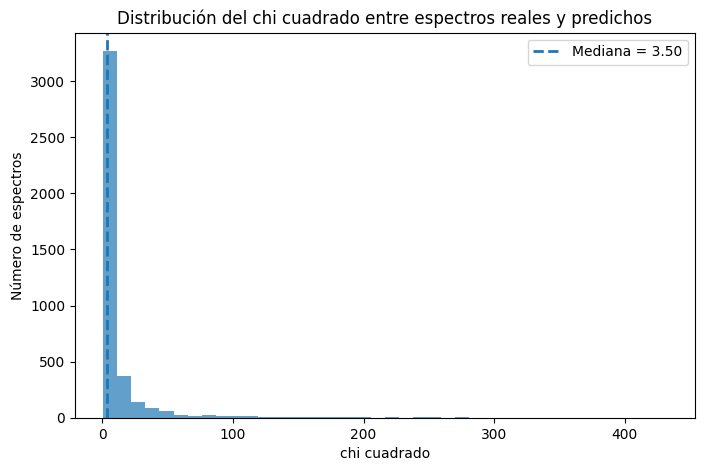

Mínimo:  0.48
Máximo:  432.12
------------------------------------------------------------------------------ 


 Modelo: dense-median 



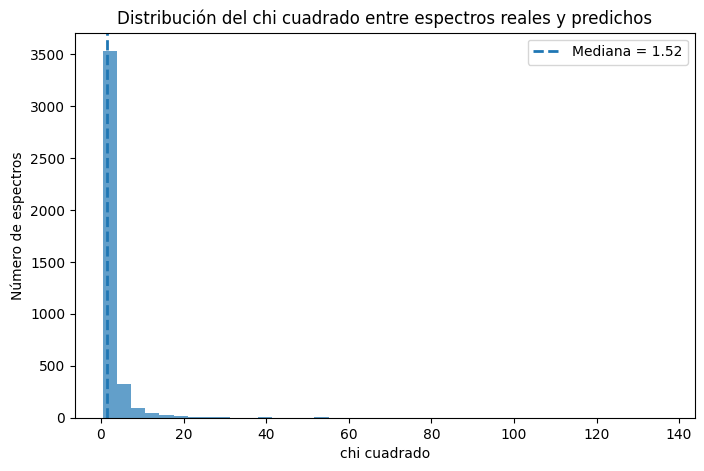

Mínimo:  0.53
Máximo:  137.00
------------------------------------------------------------------------------ 


 Modelo: dense-max 



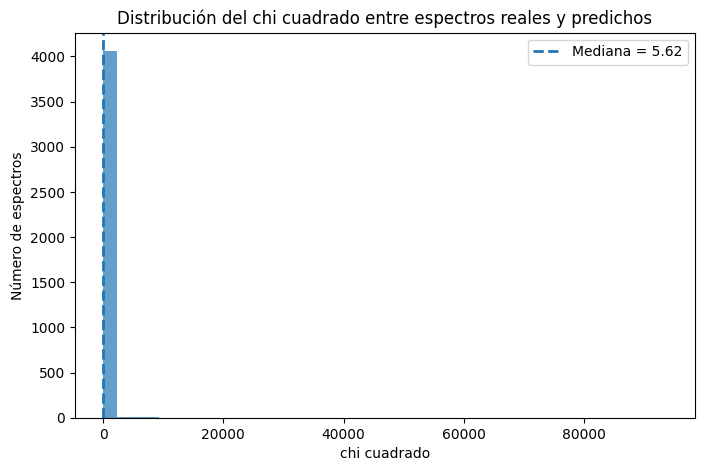

Mínimo:  0.55
Máximo:  93729.96
------------------------------------------------------------------------------ 


 Modelo: gru 



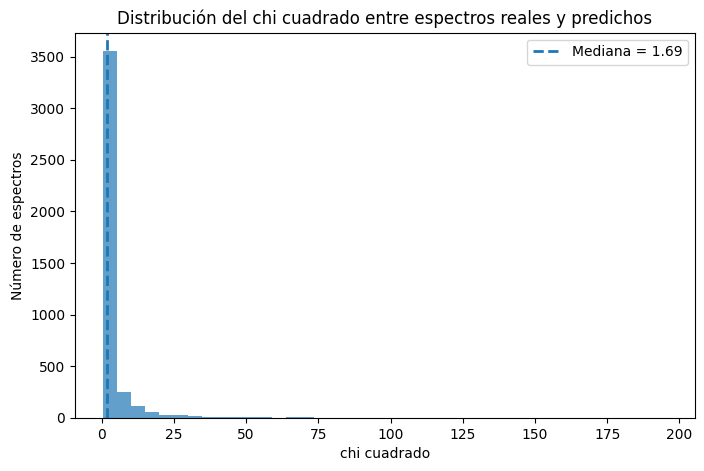

Mínimo:  0.51
Máximo:  195.58
------------------------------------------------------------------------------ 


 Modelo: birnn 



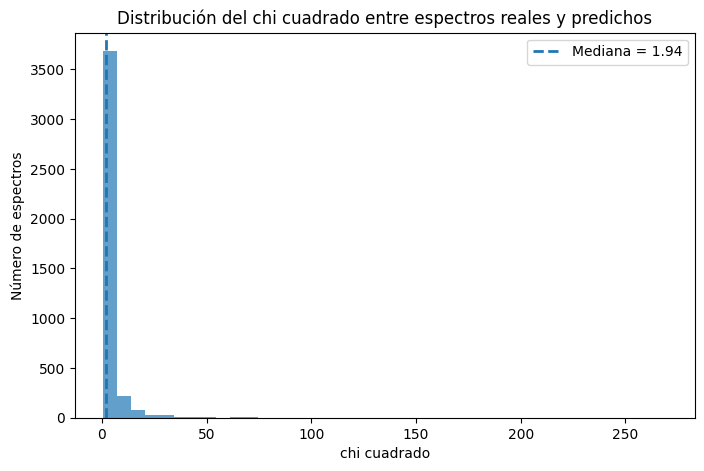

Mínimo:  0.58
Máximo:  269.77
------------------------------------------------------------------------------ 


 Modelo: birnn-attention 



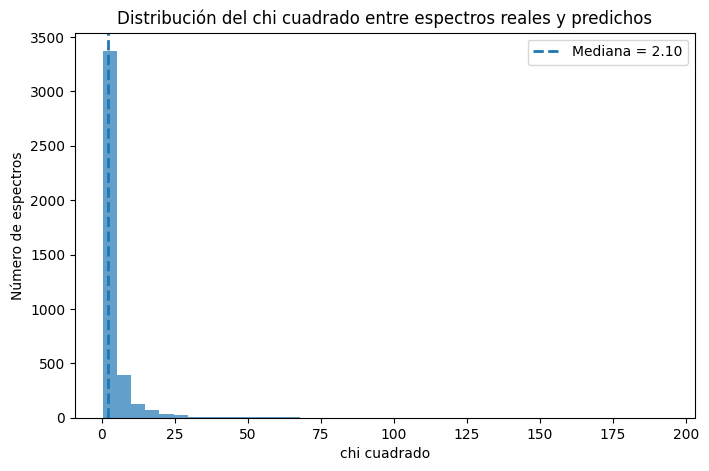

Mínimo:  0.53
Máximo:  193.42
------------------------------------------------------------------------------ 


 Modelo: cnn_v1 



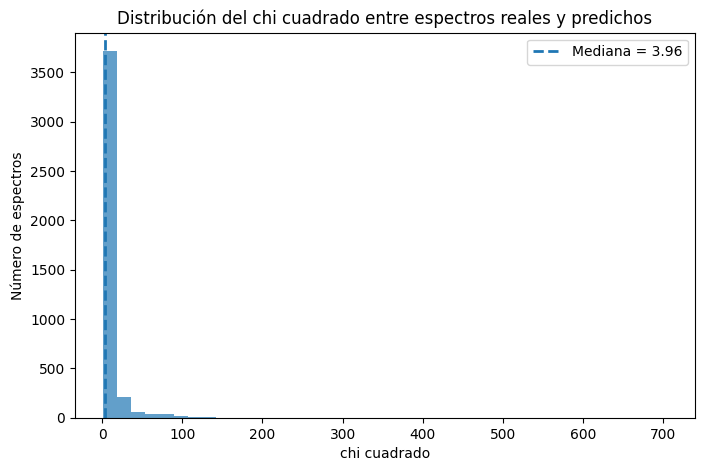

Mínimo:  1.06
Máximo:  704.61
------------------------------------------------------------------------------ 


 Modelo: cnn-v2 



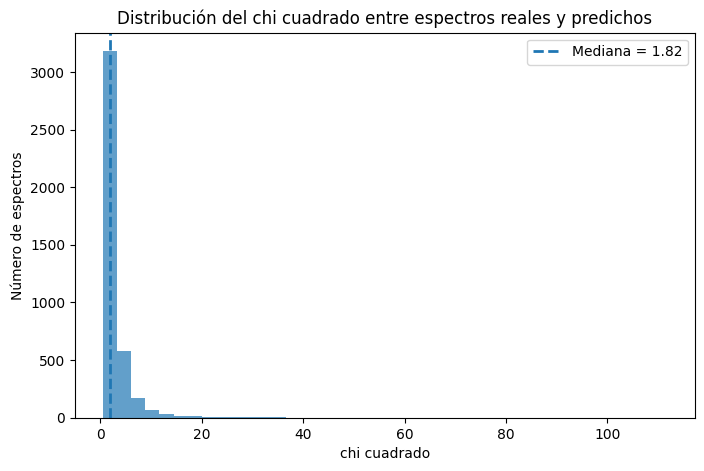

Mínimo:  0.51
Máximo:  111.73


,modelo,chi2 mediana,chi2 max,chi2 min
1,dense-median,1.522273,136.997831,0.525193
3,gru,1.694223,195.578172,0.509434
7,cnn-v2,1.824137,111.731995,0.510772
4,birnn,1.942204,269.765684,0.580268
5,birnn-attention,2.102629,193.420581,0.527079
0,dense-global,3.495036,432.121249,0.484725
6,cnn_v1,3.960349,704.609621,1.056183
2,dense-max,5.622406,93729.956489,0.548733


In [28]:
# Chi cuadrado de cada modelo sobre el conjunto de test
chi2_by_model = {}

for name, y_pred in predictions.items():
    print(f"------------------------------------------------------------------------------ \n")
    print(f"\n Modelo: {name} \n")

    chi2_by_model[name] = calculate_all_chi2( y_test, y_pred, y_ivar_test, plot=True)


# La mediana es la cifra con la que se comparan las arquitecturas en la memoria
chi2_medians = pd.DataFrame(
    [
        {"modelo": name, "chi2 mediana": float(np.median(chi2)), "chi2 max": float(np.max(chi2)), "chi2 min": float(np.min(chi2))}
        for name, chi2 in chi2_by_model.items()
    ]
).sort_values("chi2 mediana")

display(chi2_medians)

In [18]:
# Diagrama HR coloreado por chi cuadrado, para el modelo que se quiera mirar
model_name = "dense-median"

chi_median = chi2_by_model[model_name]

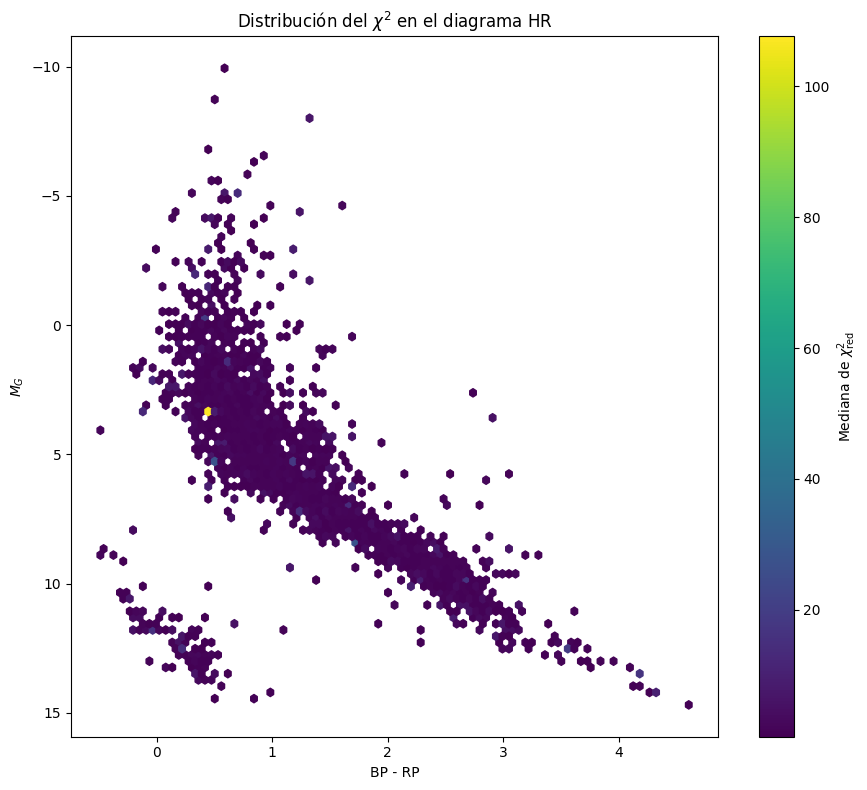

In [22]:
plot_hr_chi2_hexbin(
    bp_rp,
    g_mag,
    parallax,
    chi_median,
    gridsize=90,
    mincnt=1,
    figsize=(9, 8)
)

In [29]:
# Diagrama HR coloreado por chi cuadrado, para el modelo que se quiera mirar
model_name = "cnn-v2"

chi_median = chi2_by_model[model_name]

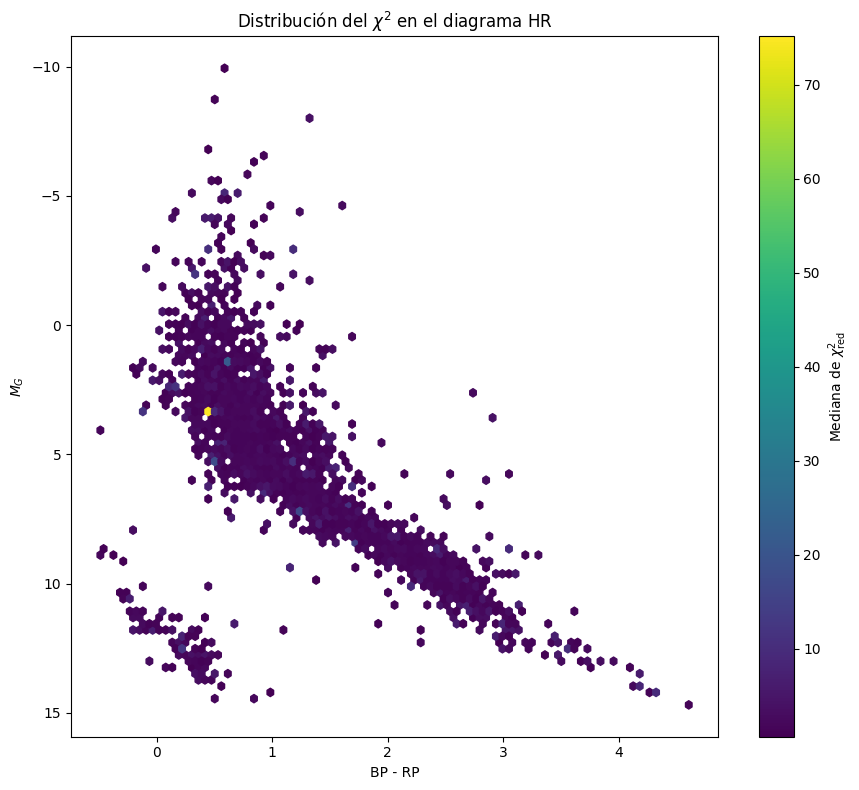

In [30]:
plot_hr_chi2_hexbin(
    bp_rp,
    g_mag,
    parallax,
    chi_median,
    gridsize=90,
    mincnt=1,
    figsize=(9, 8)
)